# 23CSE301 — Machine Learning Capstone | Review 1
## Classification Part A — Bank Marketing Term Deposit Prediction

---

### Problem Statement
Predict whether a bank customer will **subscribe to a term deposit** based on
customer demographics, account information, and marketing campaign data.

This is a **binary classification** task:
* **Target y = 1 (yes):** customer subscribed to a term deposit
* **Target y = 0 (no):** customer did not subscribe

### Why Classification?
The outcome is a discrete binary label, not a continuous number.
We therefore apply supervised classification algorithms and evaluate them
using accuracy, precision, recall, and weighted F1-score.

### Scope — Review 1 (Classification Part A)
Five algorithms are implemented in this notebook:
1. Logistic Regression (baseline)
2. K-Nearest Neighbors (KNN)
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Classifier (SVC)

Classification Part B (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP)
is reserved for Review 2 and is **not** implemented here.

### AI Assistance Acknowledgement
Code scaffolding was generated with **Google Antigravity (Gemini 2.5 Pro)**.
All analytical observations, DRAFT interpretations, and conclusions must be
verified by the project team against actual computed outputs before submission.
AI assistance is acknowledged per university academic-integrity policy.

## 2. Dataset Description

| Field | Value |
|-------|-------|
| File | `../data/bank-full.csv` |
| Delimiter | Semicolon (`;`) |
| Shape | 45 211 rows × 17 columns |
| Source | UCI Bank Marketing Dataset |
| Task | Binary Classification |

### Feature Overview

| Column | Type | Description |
|--------|------|-------------|
| `age` | int | Customer age |
| `job` | categorical | Type of job (12 categories) |
| `marital` | categorical | Marital status |
| `education` | categorical | Education level |
| `default` | categorical | Has credit in default? |
| `balance` | int | Average yearly account balance (EUR) |
| `housing` | categorical | Has housing loan? |
| `loan` | categorical | Has personal loan? |
| `contact` | categorical | Contact communication type |
| `day` | int | Last contact day of month |
| `month` | categorical | Last contact month |
| `duration` | int | Last contact duration (seconds) — **DROPPED** |
| `campaign` | int | Number of contacts in current campaign |
| `pdays` | int | Days since last contact (−1 = never contacted) |
| `previous` | int | Number of contacts before this campaign |
| `poutcome` | categorical | Outcome of previous campaign |
| `y` | categorical | **Target** — subscribed to term deposit? |

### Why `duration` is excluded
`duration` is the duration of the **last phone call with the client**.
This value is only known **after** the call ends, meaning it is not available
at prediction time (before calling the customer). Including it would constitute
**predictive-availability leakage** — the model would exploit information that
cannot exist when a real deployment prediction must be made.
The UCI dataset documentation explicitly notes this: *"this attribute should be
discarded if the intention is to have a realistic predictive model"*.

## 3. Imports and Configuration

In [1]:
# ── Standard library ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── IPython ───────────────────────────────────────────────────────────
from IPython.display import display

# ── Preprocessing ─────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Model selection ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score

# ── Classification models ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

# ── Metrics ───────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ── Global config ─────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
TARGET_COL   = 'y'

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.float_format', '{:.4f}'.format)

print("All imports successful.")
print(f"RANDOM_STATE = {RANDOM_STATE}  |  TEST_SIZE = {TEST_SIZE}")

All imports successful.
RANDOM_STATE = 42  |  TEST_SIZE = 0.2


## 4. Dataset Loading

The file uses **semicolon** (`;`) as the delimiter — not a comma.
Loading with the wrong separator would collapse all columns into one.

In [2]:
df_raw = pd.read_csv('../data/bank-full.csv', sep=';')
print(f"Loaded: {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns")
df_raw.head(6)

Loaded: 45,211 rows  x  17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no


## 5. Dataset Audit

A complete read-only inspection of the raw data before any modification.

In [3]:
# 5.1 Shape and data types
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
# 5.2 Missing-value audit
missing  = df_raw.isnull().sum().rename('Missing Count')
miss_pct = (df_raw.isnull().mean() * 100).rename('Missing %')
display(pd.concat([df_raw.dtypes.rename('dtype'), missing, miss_pct], axis=1))

,dtype,Missing Count,Missing %
age,int64,0,0.0000
job,object,0,0.0000
marital,object,0,0.0000
education,object,0,0.0000
default,object,0,0.0000
balance,int64,0,0.0000
housing,object,0,0.0000
loan,object,0,0.0000
contact,object,0,0.0000
day,int64,0,0.0000


In [5]:
# 5.3 Duplicate rows
n_dup = df_raw.duplicated().sum()
print(f"Exact duplicate rows: {n_dup}")
if n_dup == 0:
    print("=> No duplicates found.")

Exact duplicate rows: 0


=> No duplicates found.


In [6]:
# 5.4 Descriptive statistics — numerical columns
num_cols_raw = df_raw.select_dtypes(include='number').columns.tolist()
print("Numerical columns:", num_cols_raw)
display(df_raw[num_cols_raw].describe().T)

Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


,count,mean,std,min,25%,50%,75%,max
age,45211.0000,40.9362,10.6188,18.0000,33.0000,39.0000,48.0000,95.0000
balance,45211.0000,1362.2721,3044.7658,-8019.0000,72.0000,448.0000,1428.0000,102127.0000
day,45211.0000,15.8064,8.3225,1.0000,8.0000,16.0000,21.0000,31.0000
duration,45211.0000,258.1631,257.5278,0.0000,103.0000,180.0000,319.0000,4918.0000
campaign,45211.0000,2.7638,3.0980,1.0000,1.0000,2.0000,3.0000,63.0000
pdays,45211.0000,40.1978,100.1287,-1.0000,-1.0000,-1.0000,-1.0000,871.0000
previous,45211.0000,0.5803,2.3034,0.0000,0.0000,0.0000,0.0000,275.0000


In [7]:
# 5.5 Categorical columns and unique values
cat_cols_raw = df_raw.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols_raw)
print()
for col in cat_cols_raw:
    print(f"--- {col} ({df_raw[col].nunique()} unique) ---")
    print(df_raw[col].value_counts().to_string())
    print()

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

--- job (12 unique) ---
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288

--- marital (3 unique) ---
marital
married     27214
single      12790
divorced     5207

--- education (4 unique) ---
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857

--- default (2 unique) ---
default
no     44396
yes      815

--- housing (2 unique) ---
housing
yes    25130
no     20081

--- loan (2 unique) ---
loan
no     37967
yes     7244

--- contact (3 unique) ---
contact
cellular     29285
unknown      13020
telephone     2906

--- month (12 unique) ---
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     29

In [8]:
# 5.6 'unknown' sentinel values (not true NaN, but missing in semantics)
print("Columns containing 'unknown' category values:")
for col in df_raw.select_dtypes(include='object').columns:
    n = (df_raw[col] == 'unknown').sum()
    if n > 0:
        print(f"  {col:15s}: {n:6,}  ({100*n/len(df_raw):.2f} %)")

Columns containing 'unknown' category values:
  job            :    288  (0.64 %)
  education      :  1,857  (4.11 %)
  contact        : 13,020  (28.80 %)
  poutcome       : 36,959  (81.75 %)


In [9]:
# 5.7 Target class distribution
vc  = df_raw[TARGET_COL].value_counts()
pct = df_raw[TARGET_COL].value_counts(normalize=True).mul(100).round(2)
target_dist = pd.DataFrame({'Count': vc, 'Percent %': pct})
print("Target distribution (y):")
display(target_dist)
print(f"\nClass imbalance ratio  (no : yes) = {vc['no']/vc['yes']:.1f} : 1")

Target distribution (y):


,Count,Percent %
y,,
no,39922,88.3000
yes,5289,11.7000



Class imbalance ratio  (no : yes) = 7.5 : 1


In [10]:
# 5.8 Outlier analysis — IQR method on numerical features (excluding duration & target)
def iqr_report(s: pd.Series) -> pd.Series:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr    = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out  = int(((s < lo) | (s > hi)).sum())
    return pd.Series({'Q1': q1, 'Q3': q3, 'IQR': iqr,
                      'Lower Fence': lo, 'Upper Fence': hi,
                      'IQR Outliers': n_out})

audit_num = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
outlier_df = pd.DataFrame({c: iqr_report(df_raw[c]) for c in audit_num}).T
print("IQR Outlier Report:")
display(outlier_df)

IQR Outlier Report:


,Q1,Q3,IQR,Lower Fence,Upper Fence,IQR Outliers
age,33.0000,48.0000,15.0000,10.5000,70.5000,487.0000
balance,72.0000,1428.0000,1356.0000,-1962.0000,3462.0000,4729.0000
day,8.0000,21.0000,13.0000,-11.5000,40.5000,0.0000
campaign,1.0000,3.0000,2.0000,-2.0000,6.0000,3064.0000
pdays,-1.0000,-1.0000,0.0000,-1.0000,-1.0000,8257.0000
previous,0.0000,0.0000,0.0000,0.0000,0.0000,8257.0000


### Audit Findings Summary

| Item | Finding |
|------|---------|
| Shape | 45 211 rows × 17 columns |
| Missing values (NaN) | **None** — all 17 columns are fully populated |
| Duplicate rows | **None** |
| `unknown` sentinels | Present in `job` (0.64 %), `education` (4.11 %), `contact` (28.80 %), `poutcome` (81.75 %) |
| Target distribution | `no` = 39 922 (88.3 %), `yes` = 5 289 (11.7 %) — **7.5 : 1 imbalance** |
| `pdays` special code | −1 encodes "never previously contacted" (81.7 % of rows) |
| `balance` negatives | 3 766 rows have negative balance — economically valid (overdraft) |
| `duration` | Ranges 0–4 918 s; Pearson r = 0.394 with target — strong leakage risk |

**Outlier treatment decisions:**
- `age`: 487 IQR outliers (customers aged 70 +). Plausible real customers — **keep**.
- `balance`: 4 729 IQR outliers (high-value accounts and overdrafts). Economically valid — **keep**.
- `campaign`: 3 064 IQR outliers (>6 contacts). Real campaign events — **keep**.
- `pdays` and `previous`: IQR reports "outliers" because 81.7 % are coded −1 / 0. These are structural, not genuine outliers — **keep**.

## 6. Data Cleaning

### Steps performed:
1. Confirm no missing values → no imputation needed
2. Confirm no duplicate rows → no removal needed
3. Drop `duration` (predictive-availability leakage — see Section 2)
4. Retain `unknown` sentinel categories — OneHotEncoder will handle them as a valid category
5. Keep all legitimate extreme observations (see audit justification above)

### On `unknown` categories
Columns like `contact` (28.8 % unknown) and `poutcome` (81.75 % unknown) have large
proportions of the `unknown` category. Rather than imputing (which would inject
assumptions into a high-proportion group), we retain `unknown` as an explicit category
and let the encoder produce a dedicated indicator column for it. This is the most
information-preserving approach.

### On `pdays = −1`
The value −1 semantically encodes "client was not previously contacted".
This is a valid domain code, not a corrupt value. We retain it and let the model
learn the distinction between −1 and actual day counts.

In [11]:
df_clean = df_raw.copy()

# Confirm no missing values
assert df_clean.isnull().sum().sum() == 0, "Unexpected missing values found."
print("Missing values: 0  (confirmed — no imputation required)")

# Confirm no duplicates
assert df_clean.duplicated().sum() == 0, "Unexpected duplicates found."
print("Duplicate rows: 0  (confirmed — no removal required)")

# Drop duration — predictive-availability leakage
df_clean.drop(columns=['duration'], inplace=True)
print("'duration' column dropped (predictive-availability / leakage reason).")

print(f"\nWorking dataset shape: {df_clean.shape}")
print("Remaining columns:", list(df_clean.columns))

Missing values: 0  (confirmed — no imputation required)
Duplicate rows: 0  (confirmed — no removal required)
'duration' column dropped (predictive-availability / leakage reason).

Working dataset shape: (45211, 16)
Remaining columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


## 7. Exploratory Data Analysis

All visualisations are generated from the **cleaned dataset** (post-duration drop)
using the **raw, unsplit data** — no preprocessing is applied during EDA.

> All Markdown observation cells are marked **DRAFT OBSERVATION — VERIFY AGAINST
> THE ACTUAL PLOT** per academic-integrity requirements. The project team must
> verify every observation and replace draft text with confirmed findings.

### 7A — Target Class Distribution

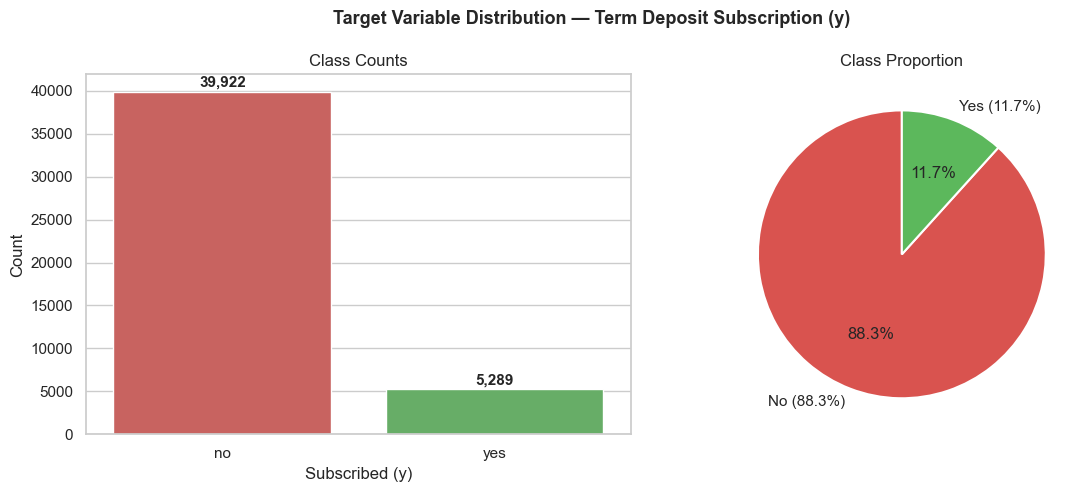

no  : 39,922  (88.30 %)
yes : 5,289  (11.70 %)
Imbalance ratio: 7.5 : 1


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable Distribution — Term Deposit Subscription (y)',
             fontsize=13, fontweight='bold')

vc = df_clean['y'].value_counts()

# Count bar
sns.countplot(x='y', data=df_clean, palette=['#d9534f', '#5cb85c'],
              order=['no', 'yes'], ax=axes[0])
axes[0].set(title='Class Counts', xlabel='Subscribed (y)', ylabel='Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 200),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(vc, labels=['No (88.3%)', 'Yes (11.7%)'],
            colors=['#d9534f', '#5cb85c'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('../data/cls_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"no  : {vc['no']:,}  ({100*vc['no']/len(df_clean):.2f} %)")
print(f"yes : {vc['yes']:,}  ({100*vc['yes']/len(df_clean):.2f} %)")
print(f"Imbalance ratio: {vc['no']/vc['yes']:.1f} : 1")

**DRAFT OBSERVATION — VERIFY AGAINST THE ACTUAL PLOT:**
The dataset exhibits severe class imbalance: approximately 88.3 % of customers
did not subscribe (`no`) versus 11.7 % who did (`yes`), yielding a 7.5 : 1 ratio.
This imbalance means that a naive classifier that always predicts `no` would achieve
≈ 88 % accuracy while being completely useless for identifying actual subscribers.
**Accuracy alone is therefore a misleading metric** for this dataset — weighted F1,
precision, and recall for the minority class (`yes`) are more informative.

*Team note: Verify the exact percentages from the printed output above and
replace draft text with confirmed numbers.*

### 7B — Numerical Feature Distributions

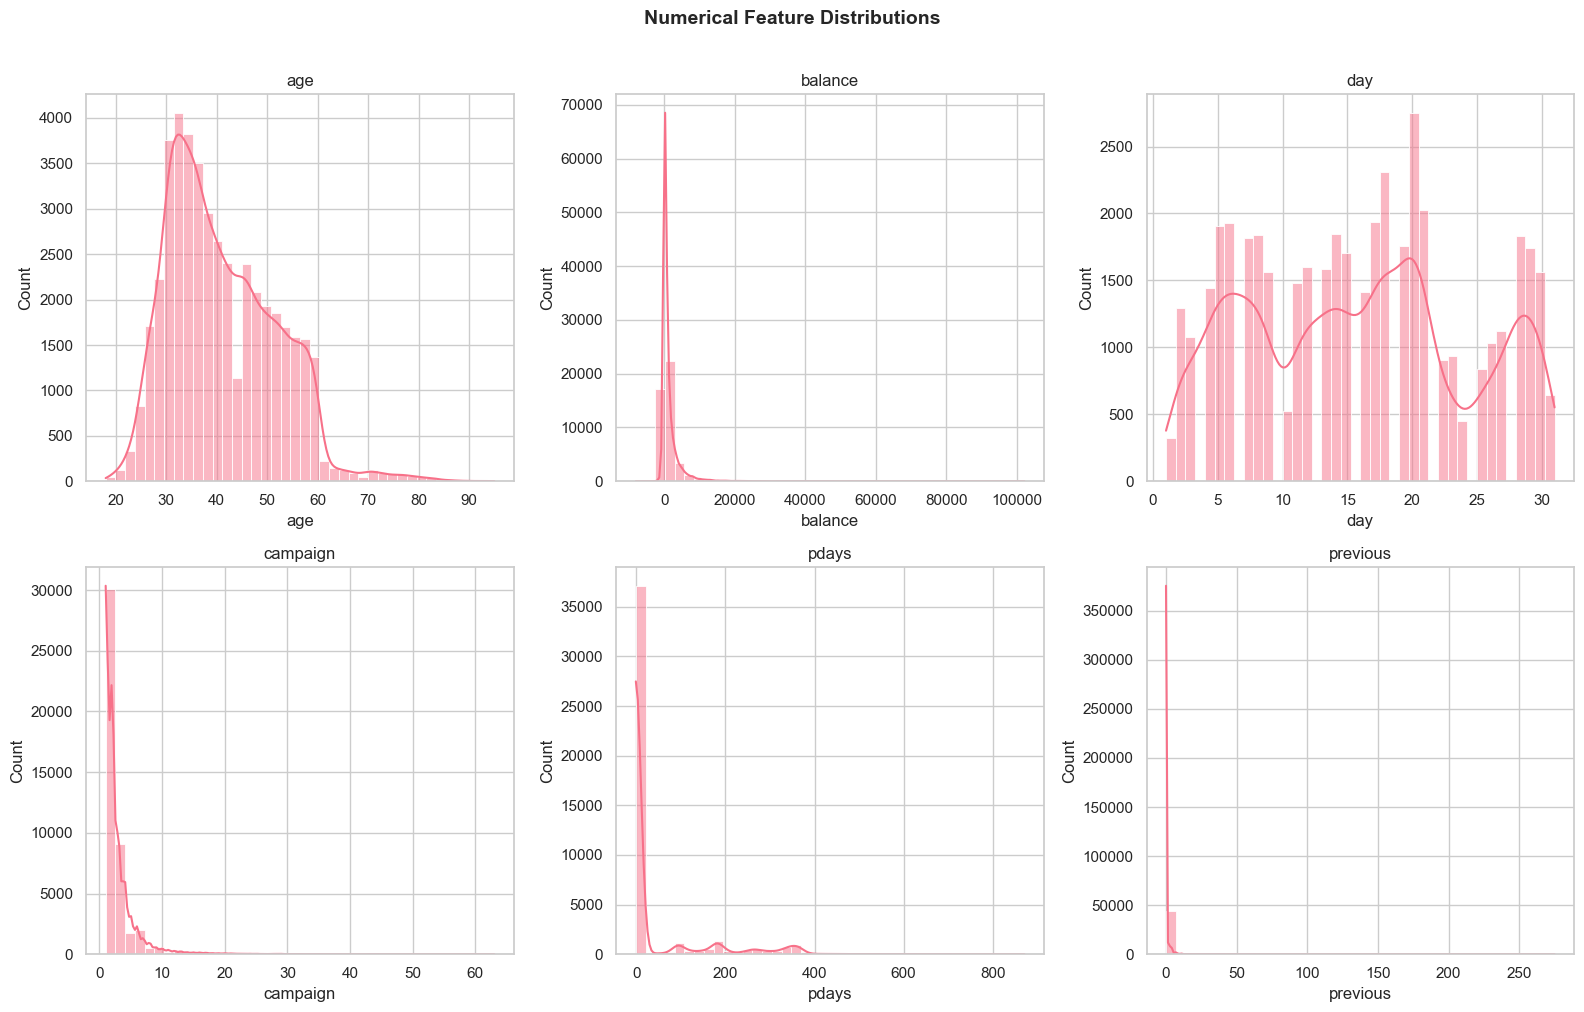

In [13]:
num_eda = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)

for ax, col in zip(axes.flatten(), num_eda):
    sns.histplot(df_clean[col], bins=40, kde=True, ax=ax)
    ax.set(title=col, xlabel=col, ylabel='Count')

plt.tight_layout()
plt.savefig('../data/cls_num_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**DRAFT OBSERVATION — VERIFY AGAINST THE ACTUAL PLOT:**
- `age`: Draft — expected to show a roughly bell-shaped distribution centred near 40.
  A long tail toward 90 + corresponds to the 487 IQR-flagged older customers.
- `balance`: Draft — expected to be heavily right-skewed with a concentration near
  zero and a long right tail (high-value accounts). Negative balances (overdrafts)
  are visible to the left of zero.
- `day`: Draft — expected to appear roughly uniform (1–31), representing call days
  spread across the month.
- `campaign`: Draft — heavily right-skewed. Most customers were contacted 1–3 times;
  a small minority were contacted many times (up to 63). The distribution likely
  shows a sharp peak at 1.
- `pdays`: Draft — dominated by the −1 sentinel (81.7 % of rows). The non-negative
  portion will appear sparse.
- `previous`: Draft — also dominated by 0 (never contacted before). Verify the
  distribution of the non-zero tail.

*Team note: Verify each distribution shape against the actual rendered histogram.*

### 7C — Categorical Feature Distributions

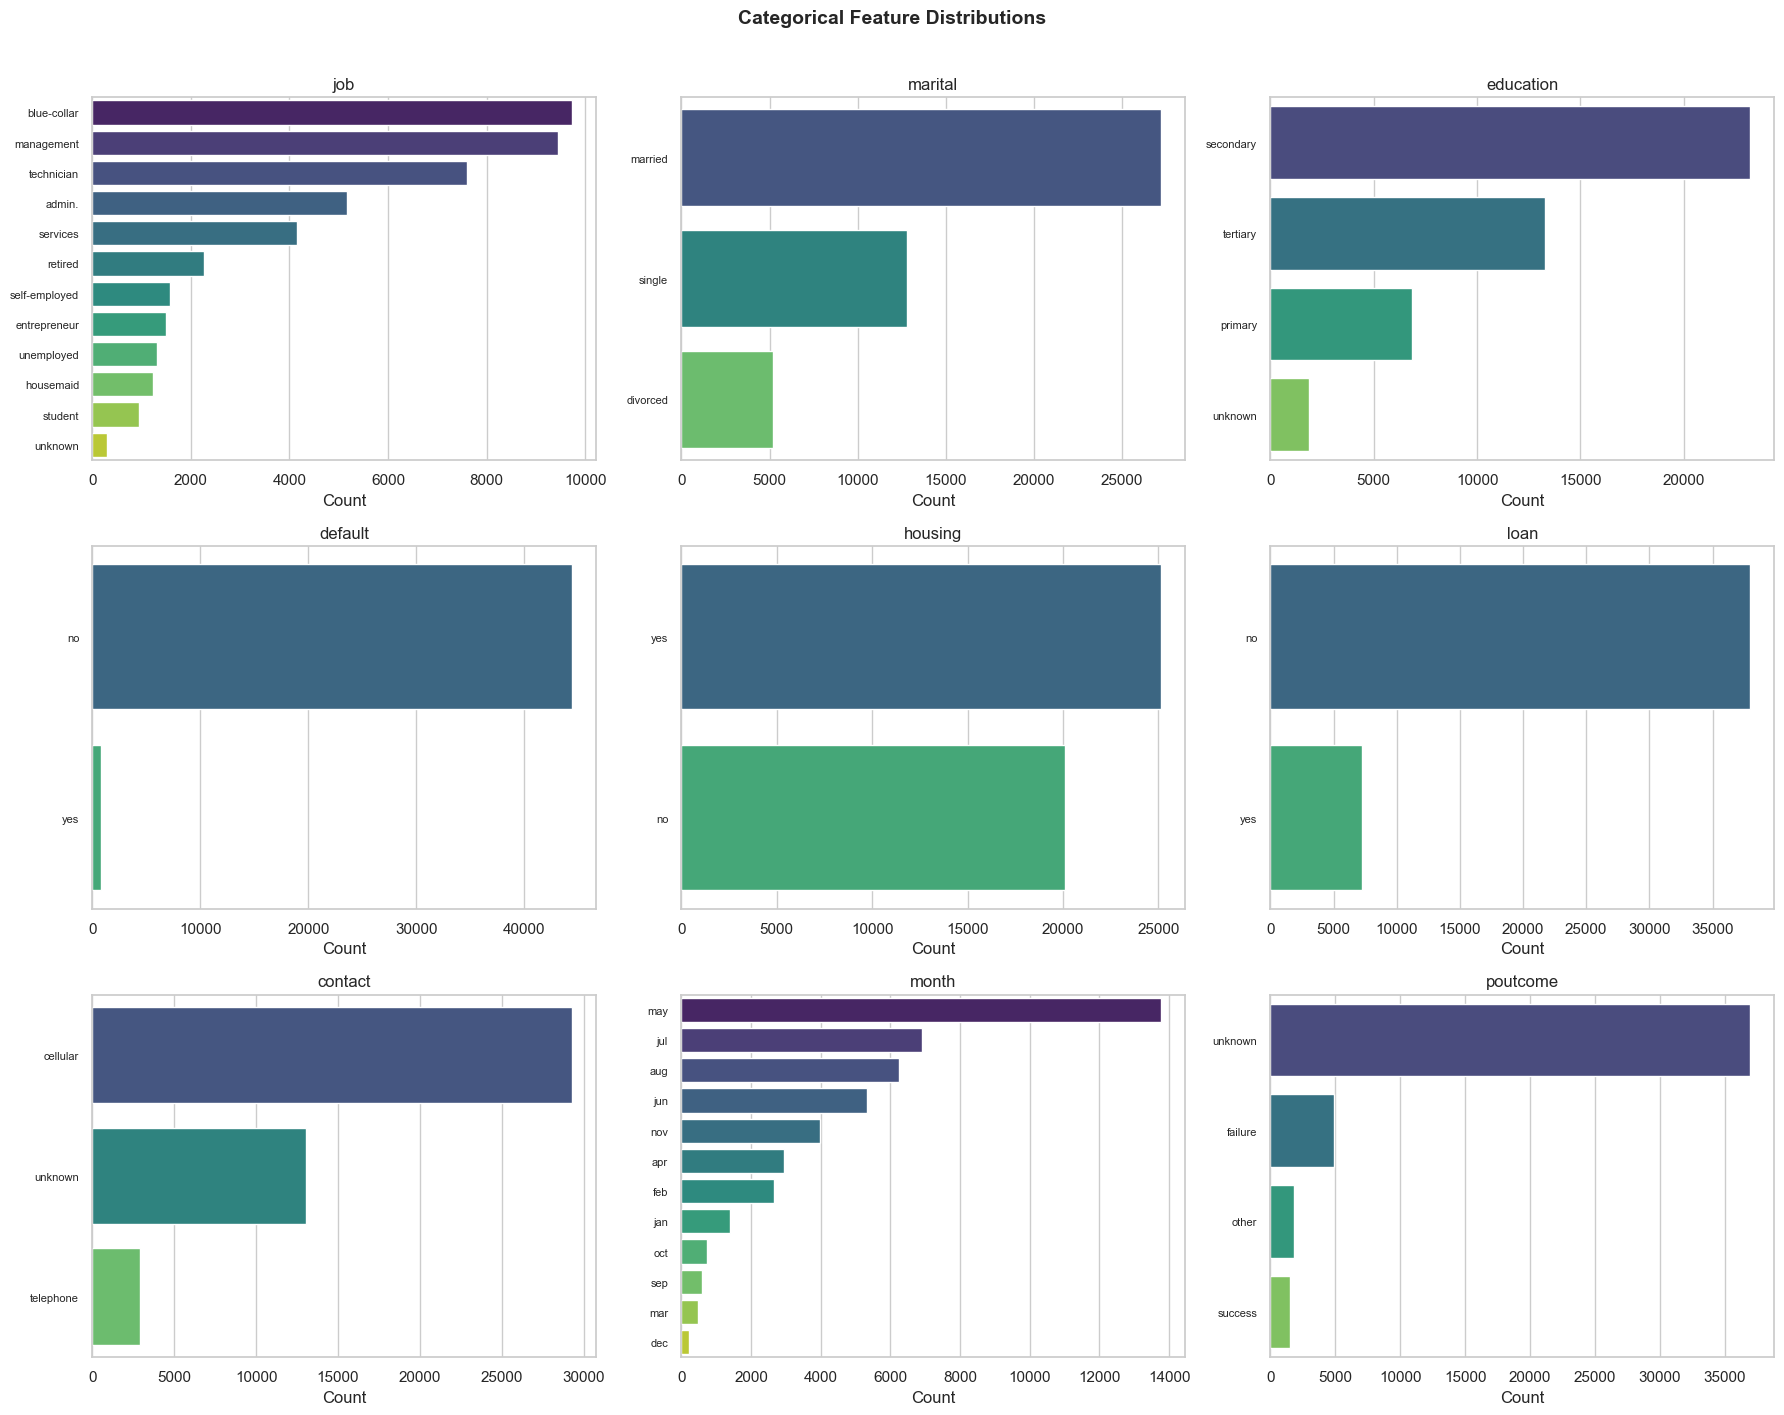

In [14]:
cat_eda = ['job', 'marital', 'education', 'default',
           'housing', 'loan', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)

for ax, col in zip(axes.flatten(), cat_eda):
    order = df_clean[col].value_counts().index
    sns.countplot(y=col, data=df_clean, order=order, ax=ax, palette='viridis')
    ax.set(title=col, xlabel='Count', ylabel='')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../data/cls_cat_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**DRAFT OBSERVATION — VERIFY AGAINST THE ACTUAL PLOT:**
- `job`: Draft — `blue-collar`, `management`, and `technician` are expected to be the
  largest groups. Verify the relative ordering.
- `marital`: Draft — `married` is expected to dominate, followed by `single`.
- `education`: Draft — `secondary` is the most common level. `unknown` is the 4th
  category (4.11 % of rows). Verify.
- `contact`: Draft — `unknown` (28.8 %) and `cellular` are expected to dominate.
  Note the very large `unknown` proportion.
- `poutcome`: Draft — `unknown` dominates (81.75 %) since most customers had no
  previous campaign. This feature has limited predictive power for the majority class.
*Team note: Verify category rankings and proportions.*

### 7D — Numerical Feature Correlation Heatmap

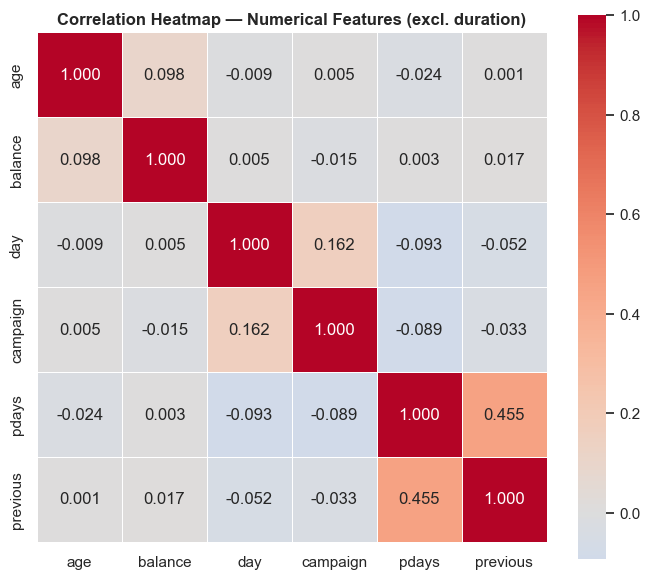

Correlations among numerical features:


,age,balance,day,campaign,pdays,previous
age,1.0000,0.0980,-0.0090,0.0050,-0.0240,0.0010
balance,0.0980,1.0000,0.0050,-0.0150,0.0030,0.0170
day,-0.0090,0.0050,1.0000,0.1620,-0.0930,-0.0520
campaign,0.0050,-0.0150,0.1620,1.0000,-0.0890,-0.0330
pdays,-0.0240,0.0030,-0.0930,-0.0890,1.0000,0.4550
previous,0.0010,0.0170,-0.0520,-0.0330,0.4550,1.0000


In [15]:
num_for_corr = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
corr = df_clean[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=ax)
ax.set_title('Correlation Heatmap — Numerical Features (excl. duration)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/cls_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlations among numerical features:")
display(corr.round(3))

**DRAFT OBSERVATION — VERIFY AGAINST THE ACTUAL PLOT:**
Draft — most numerical features are expected to show low pairwise correlations,
suggesting limited multicollinearity. `pdays` and `previous` may show moderate
positive correlation (clients contacted before were more likely to have a shorter
gap between contacts). Verify the actual coefficients from the printed matrix.

*Team note: Identify any pairs with correlation > 0.5 and assess whether
feature reduction is warranted.*

### 7E — Subscription Rate by Categorical Feature

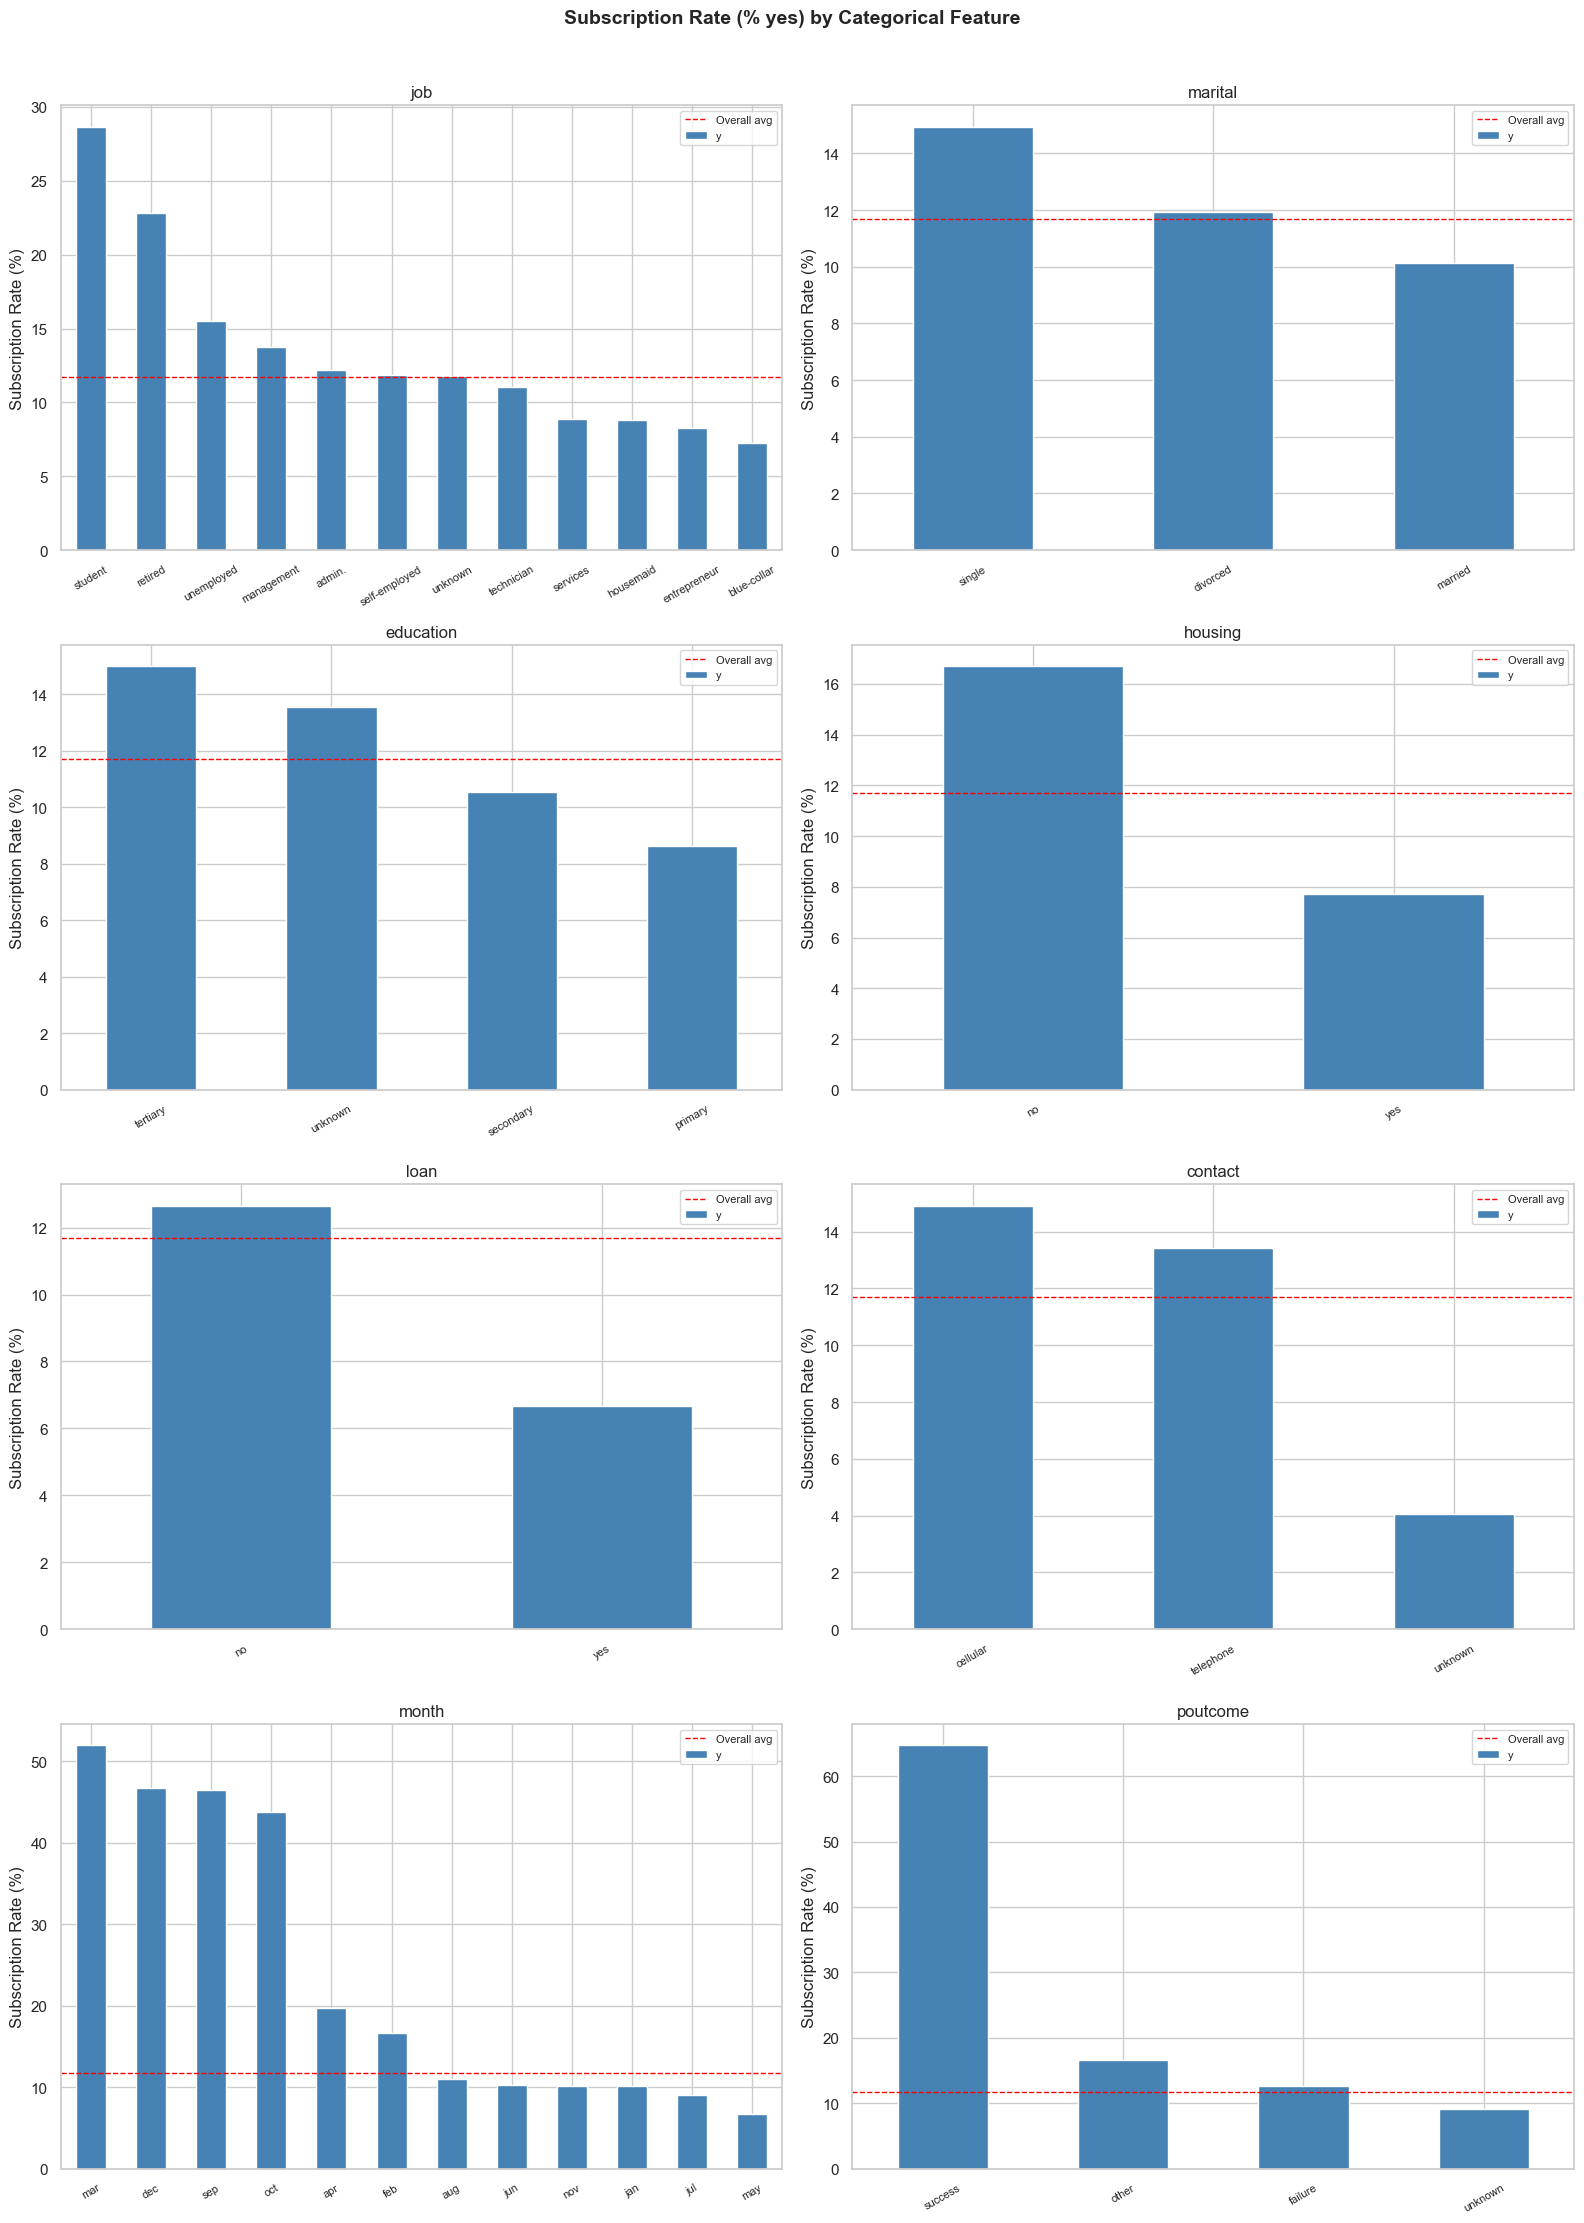

In [16]:
cat_target_cols = ['job', 'marital', 'education', 'housing',
                   'loan', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
fig.suptitle('Subscription Rate (% yes) by Categorical Feature',
             fontsize=14, fontweight='bold', y=1.01)

for ax, col in zip(axes.flatten(), cat_target_cols):
    sub_rate = (df_clean.groupby(col)['y']
                .apply(lambda x: (x == 'yes').mean() * 100)
                .sort_values(ascending=False))
    sub_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set(title=f'{col}', xlabel='', ylabel='Subscription Rate (%)')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.axhline(y=df_clean['y'].eq('yes').mean() * 100,
               color='red', linestyle='--', linewidth=1, label='Overall avg')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/cls_subrate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

**DRAFT OBSERVATION — VERIFY AGAINST THE ACTUAL PLOT:**
- `poutcome`: Draft — customers with `success` in a previous campaign are expected to
  have a dramatically higher subscription rate than the overall average (red dashed line).
  This would make `poutcome=success` a strong predictor. Verify.
- `contact`: Draft — `cellular` contact is expected to show a higher subscription rate
  than `telephone`. `unknown` contact type may have the lowest rate. Verify.
- `month`: Draft — certain months (e.g., `mar`, `sep`, `oct`, `dec`) may show unusually
  high subscription rates despite low total contact volumes. Verify whether this pattern
  is present.
- `housing` / `loan`: Draft — customers without housing or personal loans may show
  slightly higher subscription rates. Verify direction and magnitude.

*Team note: Replace each draft bullet with an observation confirmed from the actual bar chart.*

### 7F — Numerical Features vs. Target (Box Plots)

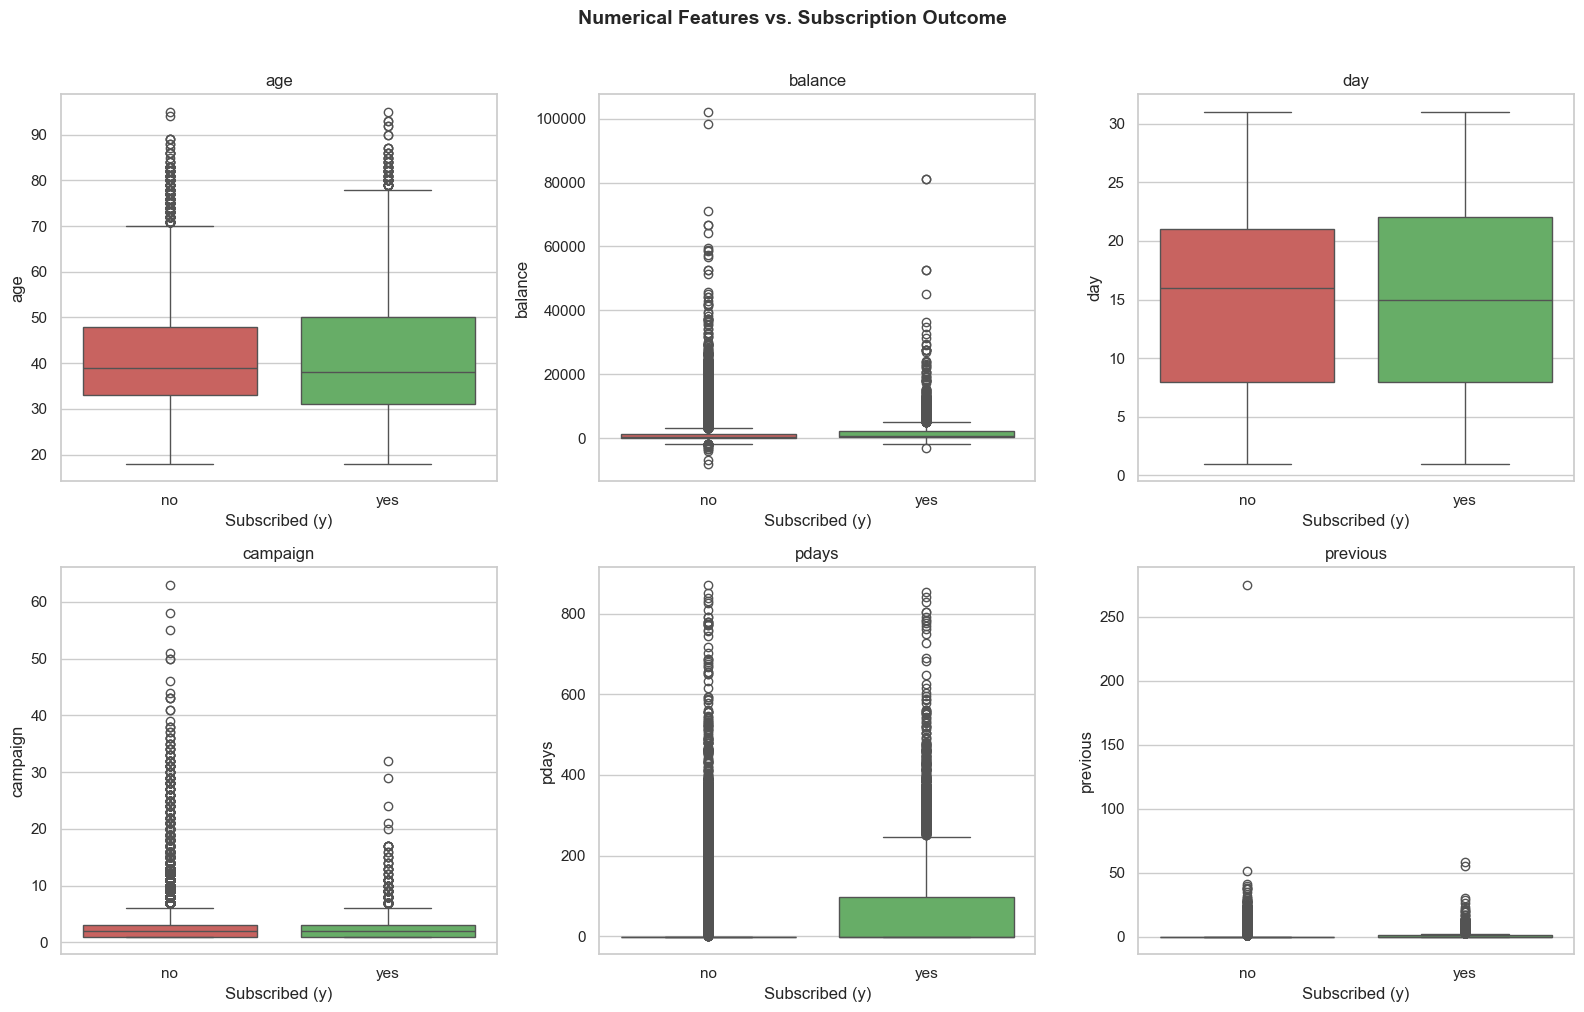

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Numerical Features vs. Subscription Outcome',
             fontsize=14, fontweight='bold', y=1.01)

num_box = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

for ax, col in zip(axes.flatten(), num_box):
    sns.boxplot(x='y', y=col, data=df_clean, order=['no', 'yes'],
                palette=['#d9534f', '#5cb85c'], ax=ax)
    ax.set(title=col, xlabel='Subscribed (y)', ylabel=col)

plt.tight_layout()
plt.savefig('../data/cls_num_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

**DRAFT OBSERVATION — VERIFY AGAINST THE ACTUAL PLOT:**
- `balance`: Draft — subscribers (`yes`) may show a higher median balance than
  non-subscribers. Verify whether the `yes` box is shifted upward.
- `campaign`: Draft — subscribers may have been contacted fewer times on average
  (lower campaign count), suggesting aggressive follow-up reduces conversion.
  Verify direction.
- `pdays`: Draft — subscribers with a prior campaign may show lower `pdays` values,
  suggesting more recent prior contact is predictive. Verify.
- `previous`: Draft — subscribers may have had more prior contacts. Verify.

*Team note: Verify the direction and magnitude of each box plot difference.*

## 8. Target Definition and Feature Selection

### Feature exclusions
| Excluded | Reason |
|----------|--------|
| `duration` | Already dropped in Section 6 — predictive-availability leakage |
| `y` | The target variable itself — must not be an input feature |

### Target encoding
Binary label encoding: `yes` → 1, `no` → 0.
The model must predict whether `y_enc == 1`.

In [18]:
# Encode target
df_clean['y_enc'] = (df_clean['y'] == 'yes').astype(int)

# Define feature matrix and target vector
drop_from_X = ['y', 'y_enc']          # exclude target columns from features
feature_cols = [c for c in df_clean.columns if c not in drop_from_X]

X = df_clean[feature_cols].copy()
y = df_clean['y_enc'].copy()

print(f"Feature matrix X : {X.shape}")
print(f"Target vector y  : {y.shape}")
print(f"\nFeature columns ({len(feature_cols)}):")
print(feature_cols)
print(f"\nTarget distribution:")
print(y.value_counts())

Feature matrix X : (45211, 15)
Target vector y  : (45211,)

Feature columns (15):
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']

Target distribution:
y_enc
0    39922
1     5289
Name: count, dtype: int64


In [19]:
# Identify numerical and categorical feature types for later preprocessing
numerical_features   = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print("Numerical features  :", numerical_features)
print("Categorical features:", categorical_features)

Numerical features  : ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## 9. Train / Test Split

A **stratified** split is required because the target is severely imbalanced
(88.3 % vs 11.7 %). Stratification ensures both train and test sets preserve
the original class proportions, preventing an accidentally skewed test set.

* **Ratio:** 80 % train / 20 % test
* **`stratify=y`** — preserves class distribution in both splits
* **`random_state=42`** — reproducibility
* The **same held-out test set** is used for all five classifiers

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print()
print("Train target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print()
print("Test target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))
print()
print("=> Stratification confirmed: class ratios preserved in both splits.")

X_train : (36168, 15)  |  y_train : (36168,)
X_test  : (9043, 15)   |  y_test  : (9043,)

Train target distribution:
y_enc
0   88.3000
1   11.7000
Name: proportion, dtype: float64

Test target distribution:
y_enc
0   88.3000
1   11.7000
Name: proportion, dtype: float64

=> Stratification confirmed: class ratios preserved in both splits.


## 10. Preprocessing Pipeline

A `ColumnTransformer` applies different transformations per feature group.

| Group | Transformer | Reason |
|-------|-------------|--------|
| Numerical (6 cols) | `StandardScaler` | Required for distance-based models (KNN, SVC) and Logistic Regression |
| Categorical (9 cols) | `OneHotEncoder(handle_unknown='ignore')` | Converts categories to binary indicator columns; `handle_unknown='ignore'` prevents errors on unseen labels |

**Leakage prevention:**
`preprocessor.fit()` is called **only on `X_train`**.
`X_test` is only **transformed**, not fitted — no test statistics leak into preprocessing.

### Special case — Gaussian Naive Bayes
`GaussianNB` expects dense arrays. The `ColumnTransformer` with
`sparse_output=False` on the OHE produces a dense numpy array, which is
compatible with GaussianNB directly.

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat',
         OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features),
    ],
    remainder='drop'
)

# Fit ONLY on training data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)    # transform only

print(f"Processed train shape : {X_train_proc.shape}")
print(f"Processed test  shape : {X_test_proc.shape}")
print(f"Data type             : {type(X_train_proc)}")

Processed train shape : (36168, 50)
Processed test  shape : (9043, 50)
Data type             : <class 'numpy.ndarray'>


In [22]:
# Recover processed feature names for importance plots
num_names_out = numerical_features.copy()
cat_names_out = (preprocessor
                 .named_transformers_['cat']
                 .get_feature_names_out(categorical_features)
                 .tolist())
proc_feature_names = num_names_out + cat_names_out
print(f"Total processed features: {len(proc_feature_names)}")

Total processed features: 50


## Classification Models — Shared Evaluation Helper

In [23]:
# ── Shared metrics helper ─────────────────────────────────────────────
CLASS_NAMES = ['no (0)', 'yes (1)']

def evaluate_classifier(name: str, y_true, y_pred) -> dict:
    '''Compute Accuracy, weighted Precision, Recall, F1 for a classifier.'''
    return {
        'Model'      : name,
        'Accuracy'   : round(accuracy_score(y_true, y_pred), 4),
        'Precision'  : round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall'     : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Weighted F1': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

def plot_cm(y_true, y_pred, model_name: str, ax):
    '''Plot a labelled confusion matrix on the given Axes.'''
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['no (0)', 'yes (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(model_name, fontsize=11, fontweight='bold')

all_results    = []
all_preds      = {}
trained_models = {}

print("Helpers ready.")

Helpers ready.


## 11. Logistic Regression

**Role:** Baseline linear classifier. Logistic Regression models the probability
of the positive class (subscription = 1) as a sigmoid function of a linear
combination of features. Its coefficient magnitudes (after standardisation) can
indicate which features most strongly push the prediction toward `yes` or `no`.

**Configuration:**
* `max_iter=1000` — increased from the default 100 to ensure convergence on this
  45 k-row dataset with many one-hot-encoded categorical features.
* `random_state=42` for reproducibility.
* `solver='lbfgs'` (default) — suitable for multiclass and large datasets.

In [ ]:
# Draw a mathematical boundary and estimate probability
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_proc, y_train)
y_pred_lr = lr.predict(X_test_proc)

trained_models['Logistic Regression'] = lr
all_preds['Logistic Regression']      = y_pred_lr
all_results.append(evaluate_classifier('Logistic Regression', y_test, y_pred_lr))

print("Logistic Regression — Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['no', 'yes']))

Logistic Regression — Classification Report:
              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.66      0.18      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.87      9043



In [25]:
# Top-10 most influential features by coefficient magnitude
coef = lr.coef_[0]
coef_df = (
    pd.DataFrame({'Feature': proc_feature_names, 'Coefficient': coef})
    .reindex(pd.Series(np.abs(coef)).sort_values(ascending=False).index)
    .head(10)
    .reset_index(drop=True)
)
print("Top-10 features by |coefficient| (Logistic Regression):")
display(coef_df)

Top-10 features by |coefficient| (Logistic Regression):


,Feature,Coefficient
0,poutcome_success,1.4779
1,month_mar,1.1162
2,month_jan,-1.0486
3,contact_unknown,-0.9785
4,month_nov,-0.7994
5,poutcome_failure,-0.7856
6,month_aug,-0.7683
7,month_sep,0.7264
8,month_oct,0.6718
9,poutcome_unknown,-0.6538


**DRAFT OBSERVATION — VERIFY AGAINST THE ACTUAL REPORT:**
Logistic Regression serves as the linear baseline. Because features are
standardised, coefficient magnitudes are comparable across features.
Draft — features such as `poutcome_success`, `contact_unknown`, and
`month_*` may appear with large coefficients, indicating they are the
most influential linear separators. The classification report will show
whether the model is biased toward the majority class (`no`) due to imbalance.

*Team note: After running, check whether the `yes` class recall is much lower
than `no` class recall — a sign that the linear model struggles with imbalance.*

## 12. K-Nearest Neighbors (KNN)

KNN classifies a point by majority vote among its k nearest neighbours in feature
space. It is a **non-parametric**, **instance-based** learner with no explicit
training phase (it memorises the training data).

**Key consideration:** KNN is highly sensitive to feature scale because it computes
Euclidean distances. `StandardScaler` (applied in the preprocessing step) is
therefore essential — without scaling, high-magnitude features like `balance`
would dominate the distance calculation.

**Configuration:** `n_neighbors=5` is a standard default for Review 1.
Exhaustive tuning is reserved for Review 2.

In [26]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_proc, y_train)
y_pred_knn = knn.predict(X_test_proc)

trained_models['KNN'] = knn
all_preds['KNN']      = y_pred_knn
all_results.append(evaluate_classifier('KNN', y_test, y_pred_knn))

print("KNN (k=5) — Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['no', 'yes']))

KNN (k=5) — Classification Report:
              precision    recall  f1-score   support

          no       0.90      0.98      0.94      7985
         yes       0.55      0.20      0.29      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.59      0.61      9043
weighted avg       0.86      0.89      0.86      9043



**DRAFT OBSERVATION — VERIFY AGAINST THE ACTUAL REPORT:**
Draft — KNN may perform competitively with Logistic Regression on accuracy
but is expected to be sensitive to the class imbalance, since the 5 nearest
neighbours are likely to be predominantly `no` class in a 7.5 : 1 imbalanced
neighbourhood. This may result in lower recall for `yes`.

*Team note: Compare KNN vs. Logistic Regression precision and recall for
the minority class (`yes`) in the final comparison table.*

## 13. Gaussian Naive Bayes

Naive Bayes classifiers apply Bayes' theorem with the **strong (naive)
conditional independence assumption**: all features are assumed to be
independent of each other given the class label. Despite this assumption
being violated in practice, Naive Bayes often performs well and is
computationally efficient.

**Gaussian NB** additionally assumes each numerical feature follows a
Gaussian (normal) distribution within each class.

**Dense array requirement:** `GaussianNB` requires a dense numpy array.
The `ColumnTransformer` with `sparse_output=False` on the OneHotEncoder
already produces a dense array, so no additional conversion is needed.

In [ ]:
# Use probability: given these features, is YES or NO more likely

gnb = GaussianNB()
gnb.fit(X_train_proc, y_train)
y_pred_gnb = gnb.predict(X_test_proc)

trained_models['Gaussian NB'] = gnb
all_preds['Gaussian NB']      = y_pred_gnb
all_results.append(evaluate_classifier('Gaussian NB', y_test, y_pred_gnb))

print("Gaussian Naive Bayes — Classification Report:")
print(classification_report(y_test, y_pred_gnb, target_names=['no', 'yes']))

Gaussian Naive Bayes — Classification Report:
              precision    recall  f1-score   support

          no       0.93      0.90      0.91      7985
         yes       0.37      0.46      0.41      1058

    accuracy                           0.85      9043
   macro avg       0.65      0.68      0.66      9043
weighted avg       0.86      0.85      0.85      9043



**DRAFT OBSERVATION — VERIFY AGAINST THE ACTUAL REPORT:**
Draft — Gaussian NB may show lower overall accuracy than tree or linear models
because the independence assumption is strongly violated (e.g., `pdays` and
`previous` are correlated). However, it may recall a higher proportion of
`yes` class subscribers than the other models if the class-conditional
distributions are sufficiently separated. Verify from the actual classification report.

*Team note: Note the `yes` class precision and recall specifically.*

## 14. Decision Tree Classifier

A Decision Tree recursively partitions the feature space by selecting splits
that maximise information gain (or Gini impurity reduction). It produces an
interpretable model where predictions can be traced along a root-to-leaf path.

**Configuration:**
* `max_depth=5` — limits tree depth to prevent severe overfitting on the
  45 k-row training set. An unlimited tree would memorise training data.
* `random_state=42` for reproducibility.
* `class_weight='balanced'` is NOT applied here (baseline comparison); it
  can be explored in Review 2 to address class imbalance.

In [ ]:
# Keep asking the best questions until the customers can be separated into classes.
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train_proc, y_train)
y_pred_dt = dt.predict(X_test_proc)

trained_models['Decision Tree'] = dt
all_preds['Decision Tree']      = y_pred_dt
all_results.append(evaluate_classifier('Decision Tree', y_test, y_pred_dt))

print("Decision Tree (max_depth=5) — Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['no', 'yes']))

Decision Tree (max_depth=5) — Classification Report:
              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.69      0.15      0.24      1058

    accuracy                           0.89      9043
   macro avg       0.80      0.57      0.59      9043
weighted avg       0.87      0.89      0.86      9043



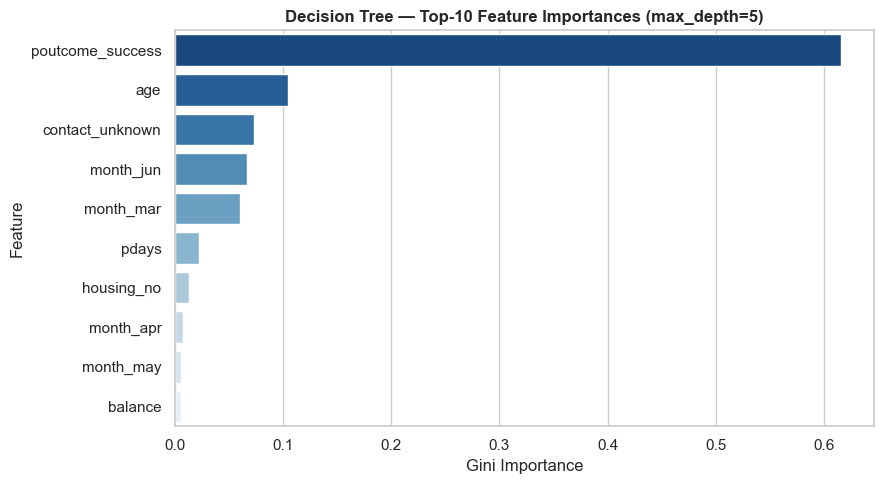

Top-10 features (Decision Tree):


,Feature,Importance
0,poutcome_success,0.6154
1,age,0.1049
2,contact_unknown,0.0732
3,month_jun,0.0673
4,month_mar,0.0607
5,pdays,0.0228
6,housing_no,0.0133
7,month_apr,0.0081
8,month_may,0.0064
9,balance,0.0057


In [29]:
# Feature importance — Decision Tree
fi_dt = (
    pd.DataFrame({'Feature': proc_feature_names,
                  'Importance': dt.feature_importances_})
    .sort_values('Importance', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=fi_dt, palette='Blues_r', ax=ax)
ax.set_title('Decision Tree — Top-10 Feature Importances (max_depth=5)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.savefig('../data/cls_dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top-10 features (Decision Tree):")
display(fi_dt)

**DRAFT OBSERVATION — VERIFY AGAINST THE ACTUAL REPORT:**
Draft — the Decision Tree may show higher recall on the majority class (`no`)
at the expense of minority class (`yes`) recall when `max_depth=5`.
The feature importance plot is expected to surface the most discriminative
variables; examine whether `poutcome`, `contact`, or `month` features appear
prominently. Verify from the actual importance values.

*Team note: Identify the top-3 features from the printed table and explain
their domain significance.*

## 15. Support Vector Classifier (SVC)

SVC finds the hyperplane that maximises the margin between the two classes in
the transformed feature space. The RBF (radial basis function) kernel maps
features into a higher-dimensional space to handle non-linear boundaries.

**Configuration:**
- `kernel='rbf'` — handles non-linearity; suitable default for Review 1.
- `probability=False` (default) — `predict()` is sufficient for all Review 1
  metrics (Accuracy, Precision, Recall, Weighted F1). Setting `probability=True`
  triggers Platt-scaling via internal 5-fold cross-validation, which is extremely
  slow on this 45 k-row dataset. It can be enabled in Review 2 if ROC-AUC is
  required.
- `random_state=42` for reproducibility.
- Numerical features are already standardised via the ColumnTransformer pipeline.
  Scaling is essential for SVC since it is sensitive to feature magnitudes.

In [ ]:
# Find a boundary that separates the classes while keeping the maximum possible margin, 
# and RBF allows nonlinear boundaries

svc = SVC(kernel='rbf', random_state=RANDOM_STATE)
svc.fit(X_train_proc, y_train)
y_pred_svc = svc.predict(X_test_proc)

trained_models['SVC'] = svc
all_preds['SVC']      = y_pred_svc
all_results.append(evaluate_classifier('SVC', y_test, y_pred_svc))

print("SVC (rbf kernel) — Classification Report:")
print(classification_report(y_test, y_pred_svc, target_names=['no', 'yes']))

SVC (rbf kernel) — Classification Report:
              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.66      0.19      0.29      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043



**DRAFT OBSERVATION — VERIFY AGAINST THE ACTUAL REPORT:**
Draft — SVC with RBF kernel is expected to be competitive in accuracy.
However, with the default C and gamma parameters on an imbalanced dataset,
it may still lean toward predicting the majority class.
Compare its weighted F1 against the other models in the final comparison table.

*Team note: Note training time — SVC on 36 k rows may take 1–3 minutes.
Verify that the model completed successfully.*

## 16. Model Evaluation — Consolidated Metrics

All five models are evaluated on the **same held-out test set**
(`X_test_proc`, `y_test`). Results are generated programmatically —
no values are hardcoded.

In [31]:
results_df = (
    pd.DataFrame(all_results)
    .sort_values('Weighted F1', ascending=False)
    .reset_index(drop=True)
)
results_df.index += 1
results_df.index.name = 'Rank'

print("=== Classification Part A — Test-Set Performance (ranked by Weighted F1) ===")
display(results_df)

=== Classification Part A — Test-Set Performance (ranked by Weighted F1) ===


,Model,Accuracy,Precision,Recall,Weighted F1
Rank,,,,,
1,SVC,0.8933,0.8726,0.8933,0.8659
2,Logistic Regression,0.8933,0.8730,0.8933,0.8650
3,KNN,0.8874,0.8612,0.8874,0.8631
4,Decision Tree,0.8927,0.8740,0.8927,0.8606
5,Gaussian NB,0.8452,0.8615,0.8452,0.8525


### Why Weighted F1 as the primary ranking metric?

Given the 7.5 : 1 class imbalance in this dataset:
* **Accuracy** alone is misleading — a model predicting all `no` achieves ≈ 88.3 %
  accuracy while identifying zero subscribers.
* **Weighted F1** accounts for class imbalance by weighting each class's F1 score
  by its support (number of true instances). It is a more informative single-number
  summary for imbalanced binary classification.
* Precision and Recall are both reported for completeness and will be used in
  Review 2's ROC-AUC and threshold analysis.

## 17. Confusion Matrices — All Five Classifiers

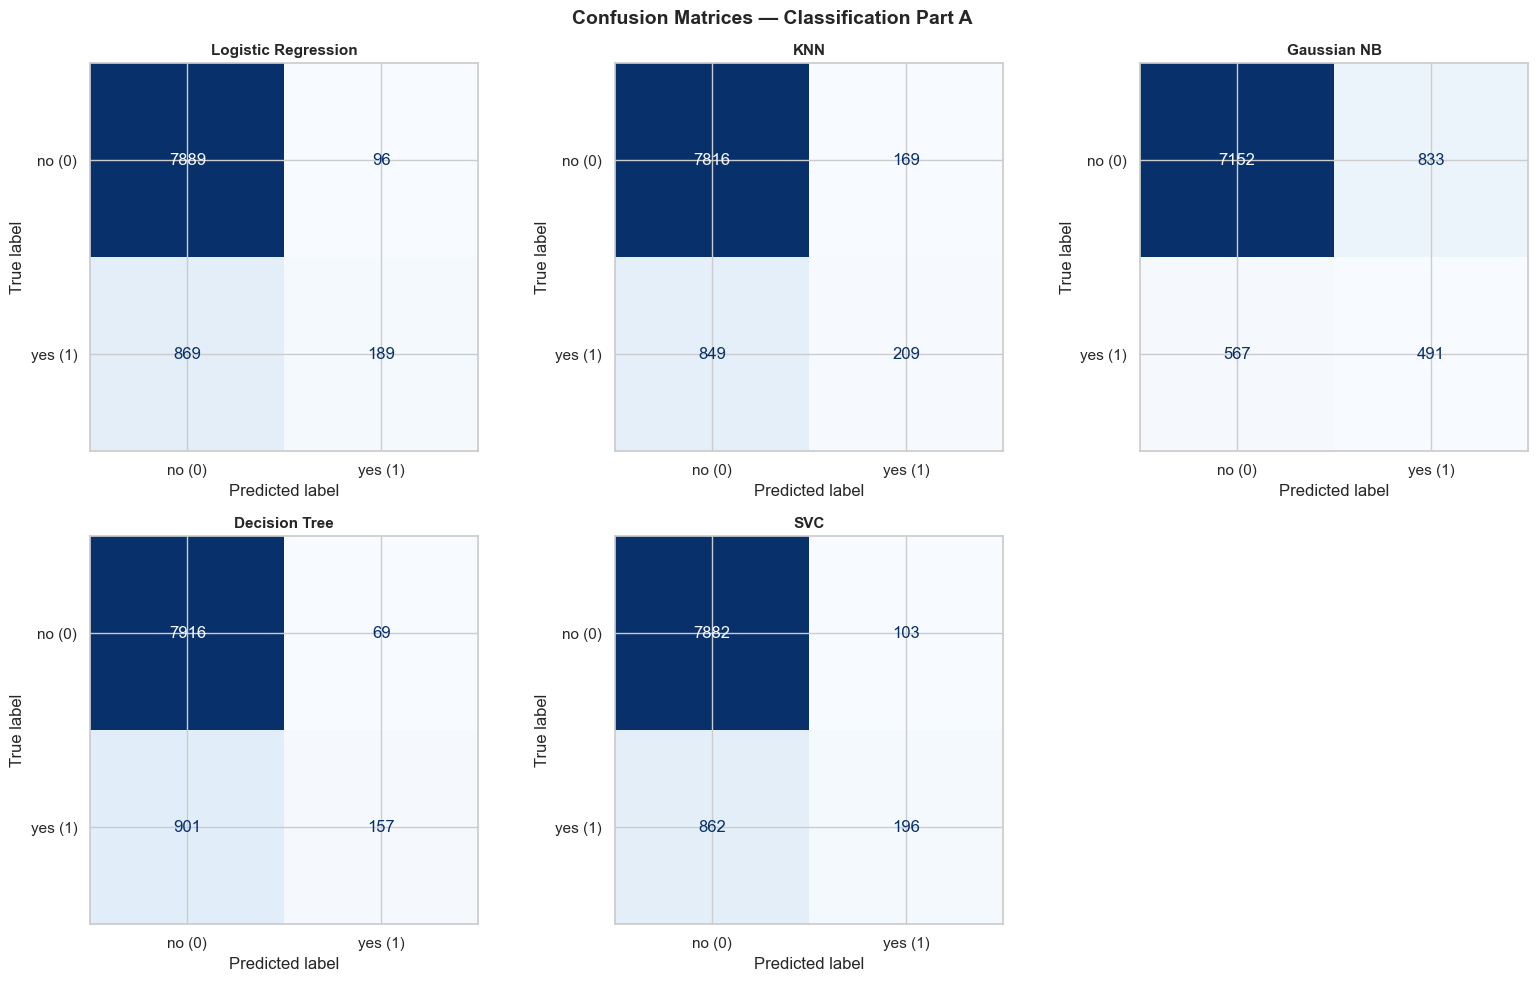

In [32]:
model_order = ['Logistic Regression', 'KNN', 'Gaussian NB', 'Decision Tree', 'SVC']
pred_map    = {
    'Logistic Regression': y_pred_lr,
    'KNN'                : y_pred_knn,
    'Gaussian NB'        : y_pred_gnb,
    'Decision Tree'      : y_pred_dt,
    'SVC'                : y_pred_svc,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices — Classification Part A',
             fontsize=14, fontweight='bold')

for ax, name in zip(axes.flatten(), model_order):
    plot_cm(y_test, pred_map[name], name, ax)

# Hide unused 6th subplot
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.savefig('../data/cls_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**DRAFT OBSERVATION — VERIFY AGAINST THE ACTUAL CONFUSION MATRICES:**
Draft — each confusion matrix is expected to show a large True Negative count
(correctly predicted `no`) and a smaller True Positive count (`yes`). The key
failure mode to examine is the **False Negative** count (bottom-left cell) —
subscribers that the model missed. A high False Negative rate means the bank
would fail to target many convertible customers.

Also note the **False Positive** count (top-right cell) — non-subscribers
incorrectly targeted as potential subscribers (wasted marketing effort).

*Team note: For each model, note the FN count and discuss which model minimises
it. This is the operationally most important error type in a marketing context.*

## 18. Class Imbalance — Analysis and Implications

### Observed imbalance

In [33]:
print("Target class distribution:")
print(f"  no  (0): {(y == 0).sum():,}  ({100*(y==0).mean():.2f} %)")
print(f"  yes (1): {(y == 1).sum():,}  ({100*(y==1).mean():.2f} %)")
print(f"  Ratio   : {(y==0).sum()/(y==1).sum():.1f} : 1")
print()
print("Naive baseline (always predict 'no') would achieve:")
print(f"  Accuracy = {100*(y==0).mean():.2f} %  (but F1 for 'yes' = 0)")

Target class distribution:
  no  (0): 39,922  (88.30 %)
  yes (1): 5,289  (11.70 %)
  Ratio   : 7.5 : 1

Naive baseline (always predict 'no') would achieve:
  Accuracy = 88.30 %  (but F1 for 'yes' = 0)


### Why accuracy alone is inadequate here

A trivial classifier that always predicts `no` would achieve **≈ 88.3 %
accuracy** while being completely useless for identifying potential subscribers.
This is the core limitation of accuracy as a metric on imbalanced datasets.

**Weighted F1-score** is more informative because it computes a per-class F1
and weights each by its prevalence, penalising models that entirely ignore the
minority class.

**Recall for the `yes` class** (True Positive Rate) is arguably the most
operationally meaningful single metric for this use case: the bank wants to
maximise the number of actual subscribers it successfully targets.
A model with low `yes`-class recall means many convertible customers are
missed, directly reducing campaign revenue.

### Review 1 approach (baseline comparison)
For Review 1, all five classifiers are trained without explicit class-imbalance
correction to establish a fair baseline.

Techniques to address imbalance (oversampling with SMOTE, `class_weight='balanced'`,
threshold adjustment, cost-sensitive learning) will be explored in Review 2
once the baseline is established and the imbalance impact is quantified.

## 19. Preliminary Comparison and Draft Findings

In [34]:
# Final ranked comparison
print("=== Final Five-Model Comparison (ranked by Weighted F1) ===")
display(results_df)

# Summary statistics
best_model = results_df.iloc[0]['Model']
best_f1    = results_df.iloc[0]['Weighted F1']
best_acc   = results_df.iloc[0]['Accuracy']
print(f"\nBest model by Weighted F1: {best_model}")
print(f"  Accuracy    : {best_acc:.4f}")
print(f"  Weighted F1 : {best_f1:.4f}")

=== Final Five-Model Comparison (ranked by Weighted F1) ===


,Model,Accuracy,Precision,Recall,Weighted F1
Rank,,,,,
1,SVC,0.8933,0.8726,0.8933,0.8659
2,Logistic Regression,0.8933,0.8730,0.8933,0.8650
3,KNN,0.8874,0.8612,0.8874,0.8631
4,Decision Tree,0.8927,0.8740,0.8927,0.8606
5,Gaussian NB,0.8452,0.8615,0.8452,0.8525



Best model by Weighted F1: SVC
  Accuracy    : 0.8933
  Weighted F1 : 0.8659


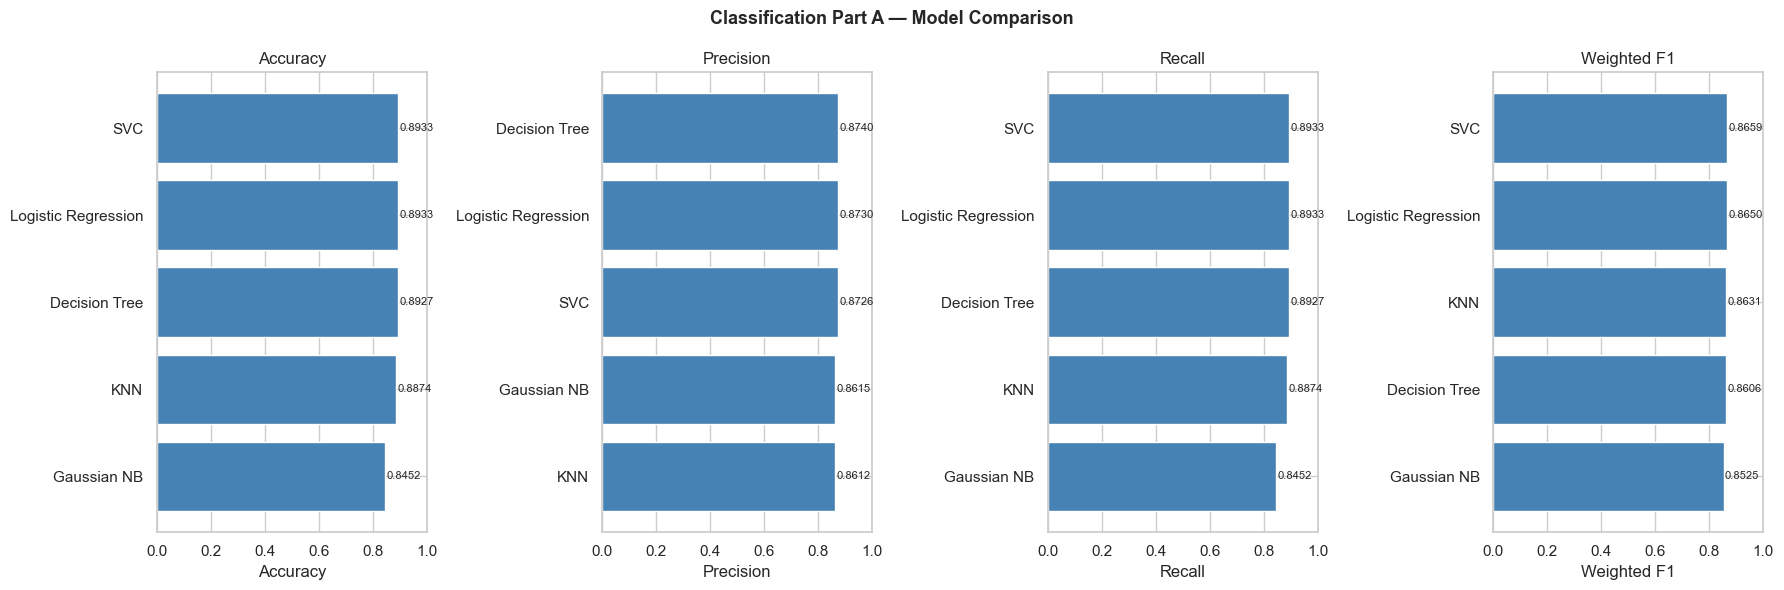

In [35]:
# Visual comparison bar chart
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'Weighted F1']
plot_df = results_df.reset_index().rename(columns={'Rank': 'rank'})

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('Classification Part A — Model Comparison', fontsize=13, fontweight='bold')

for ax, metric in zip(axes, metrics_plot):
    ordered = plot_df.sort_values(metric, ascending=False)
    bars = ax.barh(ordered['Model'], ordered[metric],
                   color='steelblue', edgecolor='white')
    ax.set(xlabel=metric, title=metric)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, ordered[metric]):
        ax.text(val + 0.005,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.savefig('../data/cls_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Draft Conclusion

> **DRAFT — All points below must be verified against the actual computed results
> and rewritten by the project team before final submission.**

1. **Best model (Weighted F1):** Draft — identify the Rank-1 entry in `results_df`.
   State its exact Accuracy, Precision, Recall, and Weighted F1.

2. **Class imbalance impact:** Draft — note whether all five models show high
   accuracy (≥ 85 %) but low recall for the `yes` class. If so, explicitly state
   that these models are biased toward the majority class and that baseline
   accuracy overstates true performance.

3. **Confusion matrix patterns:** Draft — identify which model has the lowest
   False Negative count (fewest missed subscribers). State whether any model
   shows a non-trivial True Positive rate for the minority class.

4. **Logistic Regression (baseline):** Draft — state its Weighted F1 and compare
   it to the other models. Note which features had the largest coefficient magnitudes.

5. **Feature importance (Decision Tree):** Draft — state the top-3 features by
   Gini importance and discuss their domain significance.

6. **Path to Review 2:** The imbalance problem suggests that techniques such as
   `class_weight='balanced'`, SMOTE oversampling, and probability threshold
   calibration may substantially improve minority-class recall. These will be
   investigated in Classification Part B.

**Team instruction:** Replace each draft bullet with one factual, evidence-based
sentence from the actual notebook outputs. Remove this instruction box before
submission.